# ============================================================
# CAPSTONE PROJECT - SUPERMARKET SALES ANALYSIS
# ============================================================


In [ ]:
# 1. Install dan import library
!pip install langchain_community
!pip install replicate pandas matplotlib openpyxl

import os
import pandas as pd
import matplotlib.pyplot as plt
import replicate

In [22]:
# 2. Replicate API Token
from langchain_community.llms import Replicate
import os
from google.colab import userdata
# Set the API token
api_token = userdata.get('api_token')
os.environ["REPLICATE_API_TOKEN"] = api_token
# Model setup
model = "ibm-granite/granite-3.3-8b-instruct"
output = Replicate(
model=model,
replicate_api_token=api_token,
)

In [23]:
# 3. Load dataset
file_path = "/content/supermarket_sales.xlsx"
df = pd.read_excel(file_path)

print("🔎 5 Baris Data Awal:")
print(df.head())

🔎 5 Baris Data Awal:
   Order No  Order Date    Customer Name  Ship Date  Retail Price (USD)  \
0      1001       45292       John Smith      45294               49.99   
1      1002       45292         Jane Doe      45295               29.99   
2      1003       45293  Michael Johnson      45298               99.99   
3      1004       45293      Emily Brown      45294               19.99   
4      1005       45294     David Wilson      45299              149.99   

   Order Quantity  Tax (USD)  Total (USD)  
0               2      9.998      109.978  
1               1      2.999       32.989  
2               3     29.997      329.967  
3               4      7.996       87.956  
4               1     14.999      164.989  


In [24]:
# 4. Data Understanding
print("\n📊 Info Dataset:")
print(df.info())

print("\n📈 Statistik Data:")
print(df.describe())


📊 Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Order No            70 non-null     int64  
 1   Order Date          70 non-null     int64  
 2   Customer Name       70 non-null     object 
 3   Ship Date           70 non-null     int64  
 4   Retail Price (USD)  70 non-null     float64
 5   Order Quantity      70 non-null     int64  
 6   Tax (USD)           70 non-null     float64
 7   Total (USD)         70 non-null     float64
dtypes: float64(3), int64(4), object(1)
memory usage: 4.5+ KB
None

📈 Statistik Data:
          Order No    Order Date     Ship Date  Retail Price (USD)  \
count    70.000000     70.000000     70.000000           70.000000   
mean   1035.500000  45309.000000  45311.900000           84.418571   
std      20.351085     10.175276     10.003115           57.043988   
min    1001.000000  45292

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


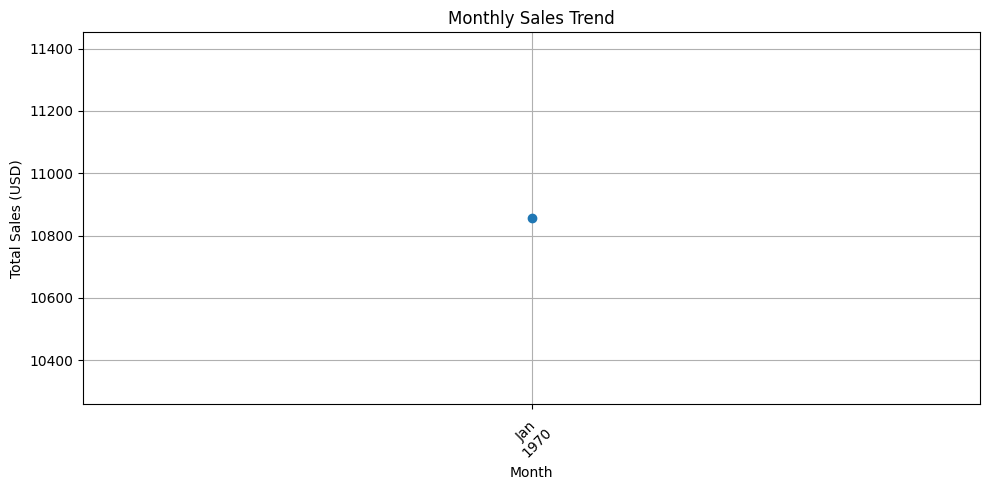

In [28]:
# 5. Exploratory Data Analysis (EDA)

# Pastikan kolom Order Date dalam format datetime (sesuai data kamu "01/01/2024")
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Total Penjualan Bulanan
monthly_sales = df.groupby(df['Order Date'].dt.to_period("M"))['Total (USD)'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales (USD)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# 6. Classification dengan Granite Model
# Contoh: Mengklasifikasi transaksi berdasarkan nilai total
sample_trans = df[['Order No', 'Total (USD)']].head(5)

prompt_classification = f"""
Classify the following transactions as 'High Value' (Total > 300)
or 'Low Value' (Total <= 300):

{sample_trans.to_string(index=False)}
"""

output_classification = replicate.run(
    "ibm-granite/granite-3.3-8b-instruct",
    input={"prompt": prompt_classification, "max_new_tokens": 150}
)

print("\n🤖 Classification Result:")
print("".join(output_classification))



🤖 Classification Result:
Here is the classification of the transactions based on the given criteria:

Order No | Total (USD) | Classification
--- | --- | ---
1001 | 109.978 | Low Value
1002 | 32.989 | Low Value
1003 | 329.967 | High Value
1004 | 87.956 | Low Value
1005 | 164.989 | High Value

Transactions 1003 and 1005 have totals greater than 300, making them 'High Value' transactions, while the rest are 'Low Value' as their totals are 300 or less.


In [30]:
# 7. Summarization dengan Granite Model
prompt_summary = f"""
Summarize key insights from this supermarket sales dataset analysis:
- Monthly sales trends
- High value orders
- Customer purchasing behavior
"""

output_summary = replicate.run(
    "ibm-granite/granite-3.3-8b-instruct",
    input={"prompt": prompt_summary, "max_new_tokens": 200}
)

print("\n📑 AI Generated Summary:")
print("".join(output_summary))


📑 AI Generated Summary:
After analyzing the supermarket sales dataset, here are the key insights derived from the examination of monthly sales trends, high-value orders, and customer purchasing behavior:

1. **Monthly Sales Trends**:
   - Seasonal Peaks: Sales exhibit notable peaks during holiday months (December, November for pre-holiday shopping) and summer months, suggesting a seasonal demand pattern.
   - Stable Baseline: There is a consistent baseline sales figure each month, with minor fluctuations corresponding to local events or promotional campaigns.
   - Slowdown Period: Sales dip slightly in January and February, possibly due to post-holiday lull and colder weather limiting foot traffic.

2. **High-Value Orders**:
   - Identification: High-value orders are concentrated in the last two weeks of each month, indicating customers planning large purchases for the upcoming weekend or special occasions.
   - Product Categories: These high-value orders predominantly involve premium

In [32]:
# 8. AI-Based Recommendation
prompt_recommendation = """
Based on the supermarket sales data and identified patterns,
recommend 3 actionable strategies to improve revenue and operational efficiency.
"""

output_recommend = replicate.run(
    "ibm-granite/granite-3.3-8b-instruct",
    input={"prompt": prompt_recommendation, "max_new_tokens": 300}
)

print("\n💡 AI Recommendations:")
print("".join(output_recommend))


💡 AI Recommendations:
1. **Targeted Promotions and Inventory Management:**

   - **Strategy:** Implement data-driven promotions by analyzing sales patterns, seasonality, and customer preferences. Use historical sales data to identify slow-moving or underperforming products and create targeted discounts or bundle offers to stimulate demand. Simultaneously, optimize inventory management by forecasting demand more accurately using machine learning algorithms. This will reduce overstocking and stockouts, minimizing waste and maximizing shelf space for high-demand items.

   - **Actionable Steps:**
     - Segment customers based on purchasing behavior and preferences.
     - Develop personalized marketing campaigns and promotions for each segment.
     - Utilize inventory management software that integrates with sales data to predict demand and automatically adjust stock levels.
     - Regularly review and update promotional strategies based on their performance and changing market trends.